# Simulation Paths | NeuralForecast
> Generate correlated sample paths for scenario analysis

## Simulation vs. Prediction Intervals: When to Use Which

NeuralForecast provides two complementary approaches for reasoning about future uncertainty:

### Prediction Intervals (`predict(level=...)`)
Prediction intervals answer: **"What range of values is the target likely to fall within at each future time step?"**

- Output: Independent confidence bands per horizon step (e.g., 90% interval at step $h$).
- Each step is treated marginally — no information about how steps relate to each other.
- Best for: monitoring, alerting, dashboarding, reporting confidence bands.

### Simulation Paths (`simulate(...)`)
Simulation paths answer: **"What are realistic *joint* future trajectories the time series could follow?"**

- Output: $N$ complete trajectories of length $H$, each representing a plausible future.
- Temporal correlations between steps are preserved — if step $h$ is high, step $h+1$ is likely high too.
- Best for: scenario analysis, portfolio optimization, supply chain planning, energy dispatch, risk assessment (VaR/CVaR), stochastic programming.

### Key Difference: Marginal vs. Joint

Consider electricity price forecasting over 24 hours. A 90% prediction interval tells you the price at hour 12 will likely be between \$40 and \$80. But it says nothing about whether hours 11, 12, and 13 will *all* be high simultaneously (a sustained price spike) or whether high and low values alternate randomly.

Simulation paths capture this joint structure. From 500 simulated paths you can compute:
- **P(total cost > budget)** — requires summing across correlated hours
- **P(at least 3 consecutive hours above \$70)** — requires temporal ordering
- **Expected shortfall (CVaR)** — requires the joint tail distribution

These questions *cannot* be answered from marginal prediction intervals alone.

## Available Simulation Methods

| Method | Temporal Correlation | Description |
|--------|---------------------|-------------|
| `gaussian_copula` (default) | AR(1) Gaussian copula | Draws correlated uniform samples via Cholesky decomposition, maps through marginal CDFs. Parametric correlation structure. |
| `schaake_shuffle` | Empirical (historical templates) | Draws independent marginal samples, reorders them to match rank structure of historical trajectory templates. Nonparametric — captures arbitrary dependence. |

**Compatible losses**:
- **`DistributionLoss`** (Normal, StudentT, Poisson, etc.) and **mixture losses** (`GMM`, `PMM`, `NBMM`) — produce arbitrary quantiles natively.
- **`MQLoss`** / **`HuberMQLoss`** — uses the model's trained quantile grid.
- **`IQLoss`** / **`HuberIQLoss`** — evaluates multiple quantiles via repeated forward passes.
- **Point losses** (`MAE`, `MSE`, etc.) — requires `prediction_intervals` (Conformal Prediction) set during `fit()` to build a quantile grid from calibration scores.

## 1. Setup

In [1]:
import logging
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

warnings.filterwarnings("ignore")
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
torch.set_float32_matmul_precision("high")

## 2. Load Data

We use the AirPassengers dataset — a classic monthly time series of airline passenger counts.

In [2]:
from neuralforecast.utils import AirPassengersDF

Y_df = AirPassengersDF.copy()
Y_train_df = Y_df[Y_df.ds <= "1959-12-31"]  # 132 months train
Y_test_df = Y_df[Y_df.ds > "1959-12-31"]    # 12 months test

print(f"Train: {len(Y_train_df)} rows, Test: {len(Y_test_df)} rows")
Y_train_df.tail()

2026-03-20 13:09:32,071	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-03-20 13:09:32,151	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Train: 132 rows, Test: 12 rows


,unique_id,ds,y
127,1.0,1959-08-31,559.0
128,1.0,1959-09-30,463.0
129,1.0,1959-10-31,407.0
130,1.0,1959-11-30,362.0
131,1.0,1959-12-31,405.0


## 3. Train Models

We train five models showcasing different loss types:
- **NHITS + GMM** — Gaussian Mixture Model, a mixture `DistributionLoss`.
- **NHITS + DistributionLoss(Normal)** — parametric distribution output.
- **NHITS + MQLoss** — Multi-Quantile Loss, directly optimizes quantile levels.
- **NHITS + IQLoss** — Implicit Quantile Loss, can evaluate any quantile at inference.
- **NHITS + MAE** with Conformal Prediction — point-loss model with calibrated prediction intervals.

Since the MAE model needs conformal prediction intervals, we pass `prediction_intervals` to `fit()`.

In [ ]:
from neuralforecast import NeuralForecast
from neuralforecast.losses.pytorch import GMM, MAE, MQLoss, DistributionLoss, IQLoss
from neuralforecast.models import NHITS
from neuralforecast.utils import PredictionIntervals

H = 12
MAX_STEPS = 100

models = [
    NHITS(h=H, input_size=36, max_steps=MAX_STEPS, loss=GMM(), alias="NHITS_GMM", scaler_type="robust"),
    NHITS(h=H, input_size=36, max_steps=MAX_STEPS, loss=DistributionLoss(distribution="Normal"), alias="NHITS_Normal", scaler_type="robust"),
    NHITS(h=H, input_size=36, max_steps=MAX_STEPS, loss=MQLoss(level=[80, 90]), alias="NHITS_MQ", scaler_type="robust"),
    NHITS(h=H, input_size=36, max_steps=MAX_STEPS, loss=IQLoss(), alias="NHITS_IQL", scaler_type="robust"),
    NHITS(h=H, input_size=36, max_steps=MAX_STEPS, loss=MAE(), alias="NHITS_MAE", scaler_type="robust"),
]

nf = NeuralForecast(models=models, freq="MS")
nf.fit(
    df=Y_train_df,
    prediction_intervals=PredictionIntervals(n_windows=2, method="conformal_error"),
)

## 4. Prediction Intervals (Baseline)

First, let's see the standard prediction intervals — these are marginal (per-step) uncertainty bands.

In [ ]:
from utilsforecast.plotting import plot_series

fcst_df = nf.predict(level=[80, 90])

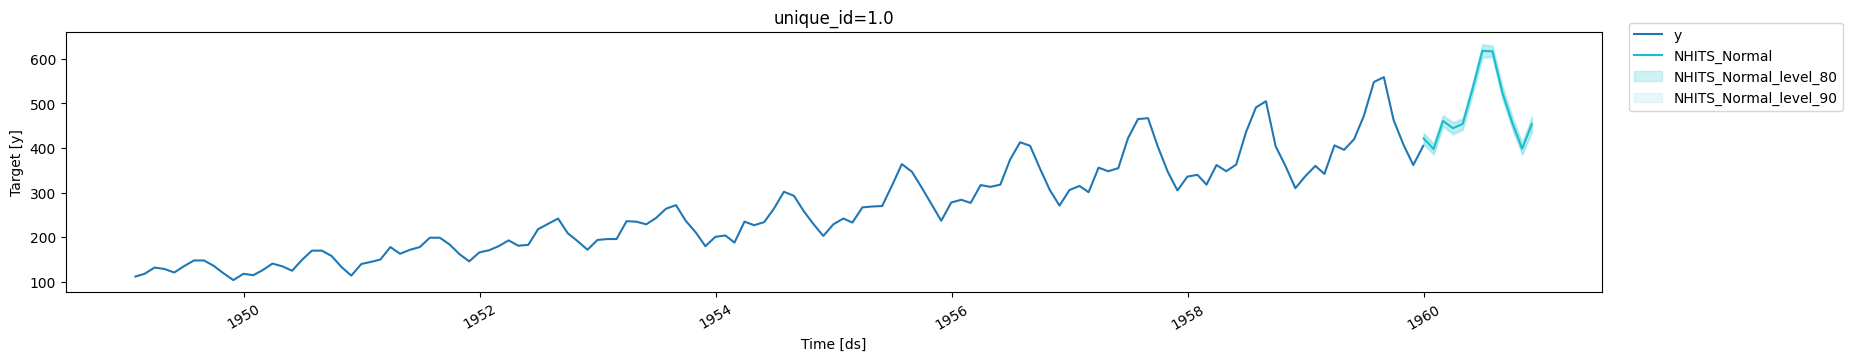

In [5]:
plot_series(Y_train_df, fcst_df, level=[80, 90], models=["NHITS_Normal"])

The shaded bands show the 80% and 90% prediction intervals. These are useful for understanding per-step uncertainty, but they do not capture the **temporal correlation** between forecast steps. Each band is computed independently.

## 5. Simulation Paths

Now let's generate correlated simulation paths using the `simulate()` method. This returns a long-format DataFrame with columns `[unique_id, ds, sample_id, model_1, model_2, ...]`.

### Plotting helper

In [6]:
def extract_sims(sim_df, model_col, uid=None):
    """Extract simulation paths as a (n_paths, H) numpy array from simulate() output."""
    if uid is None:
        uid = sim_df["unique_id"].iloc[0]
    series = sim_df[sim_df["unique_id"] == uid]
    return series.pivot(index="sample_id", columns="ds", values=model_col).values


def plot_simulations(train_df, sims, model_name, title, color="steelblue", n_show=100):
    """Plot historical data with simulated future paths and derived prediction intervals."""
    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    
    # History (last 48 months)
    hist = train_df.sort_values("ds").tail(48)
    ax.plot(hist["ds"], hist["y"], color="black", linewidth=1.5, label="History")
    
    # Future dates
    last_date = hist["ds"].iloc[-1]
    future_dates = pd.date_range(start=last_date, periods=sims.shape[1] + 1, freq="MS")[1:]
    
    # Individual paths
    for i in range(min(n_show, sims.shape[0])):
        ax.plot(future_dates, sims[i], color=color, alpha=0.05, linewidth=0.5)
    
    # Derived prediction intervals from simulations
    for q_lo, q_hi, alpha in [(0.05, 0.95, 0.15), (0.10, 0.90, 0.25), (0.25, 0.75, 0.35)]:
        lo = np.quantile(sims, q_lo, axis=0)
        hi = np.quantile(sims, q_hi, axis=0)
        ax.fill_between(future_dates, lo, hi, color=color, alpha=alpha,
                        label=f"{int((q_hi - q_lo) * 100)}% PI")
    
    # Median
    median = np.median(sims, axis=0)
    ax.plot(future_dates, median, color=color, linewidth=2, label="Median")
    
    # Actual (if available)
    ax.plot(Y_test_df["ds"], Y_test_df["y"], color="black", linestyle="--", label="Actual")
    
    ax.set_title(f"{title} — {model_name}")
    ax.legend(loc="upper left", fontsize=8)
    ax.set_xlabel("Date")
    ax.set_ylabel("Passengers")
    plt.tight_layout()
    plt.show()

### Generate simulation paths

`simulate()` generates `n_paths` correlated sample paths for every model × series combination. 

In [ ]:
N_PATHS = 500
SEED = 42

sim_df = nf.simulate(n_paths=N_PATHS, seed=SEED)

In [8]:
sim_df.head(10)

,unique_id,ds,sample_id,NHITS_GMM,NHITS_Normal,NHITS_MQ,NHITS_IQL,NHITS_MAE
0,1.0,1960-01-01,0,424.577554,424.765725,415.206802,409.314326,438.886536
1,1.0,1960-02-01,0,404.827416,404.260575,414.203812,388.755778,416.497602
2,1.0,1960-03-01,0,469.169496,469.978479,464.367880,466.584470,482.319912
3,1.0,1960-04-01,0,450.245044,451.145088,454.416200,462.261074,459.493987
4,1.0,1960-05-01,0,472.641135,471.130120,475.350769,486.486899,493.030374
5,1.0,1960-06-01,0,528.117486,527.280406,539.266724,497.874372,530.030655
6,1.0,1960-07-01,0,594.137207,592.315796,623.242188,507.372412,586.462607
7,1.0,1960-08-01,0,604.532895,604.907234,617.977478,531.723887,583.457802
8,1.0,1960-09-01,0,530.447128,529.882652,545.858492,566.198389,524.067964
9,1.0,1960-10-01,0,458.686895,458.105852,466.378017,466.831645,468.689723


### Visualize paths for each model

NHITS_GMM: simulation paths shape = (500, 12)


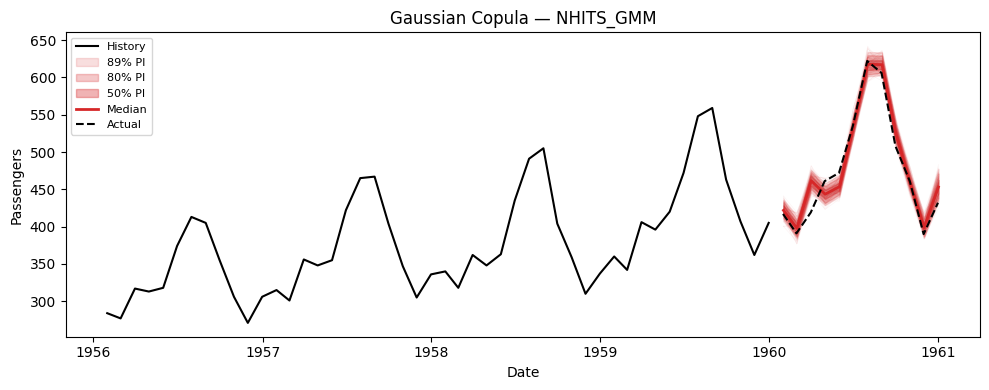

NHITS_Normal: simulation paths shape = (500, 12)


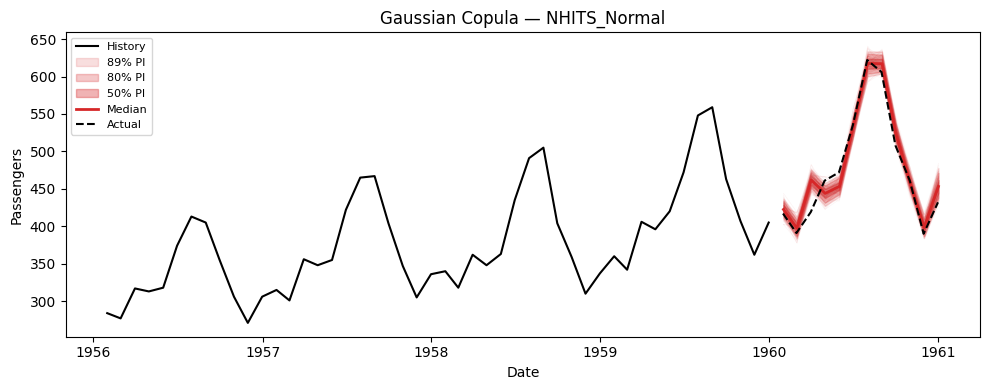

NHITS_MQ: simulation paths shape = (500, 12)


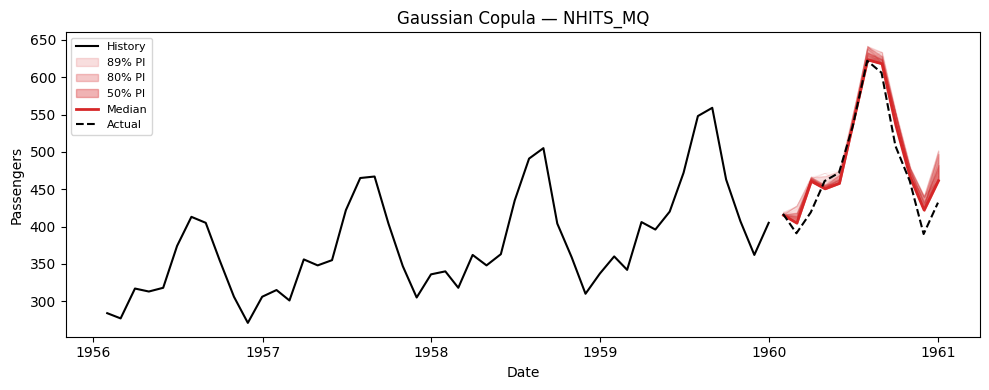

NHITS_IQL: simulation paths shape = (500, 12)


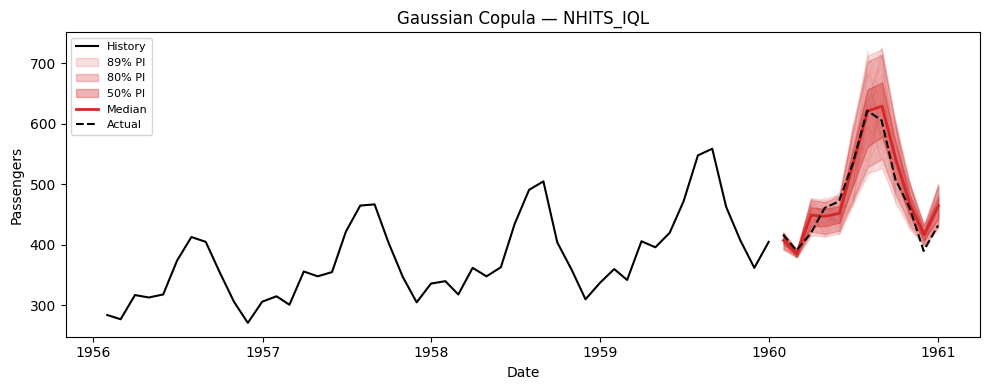

NHITS_MAE: simulation paths shape = (500, 12)


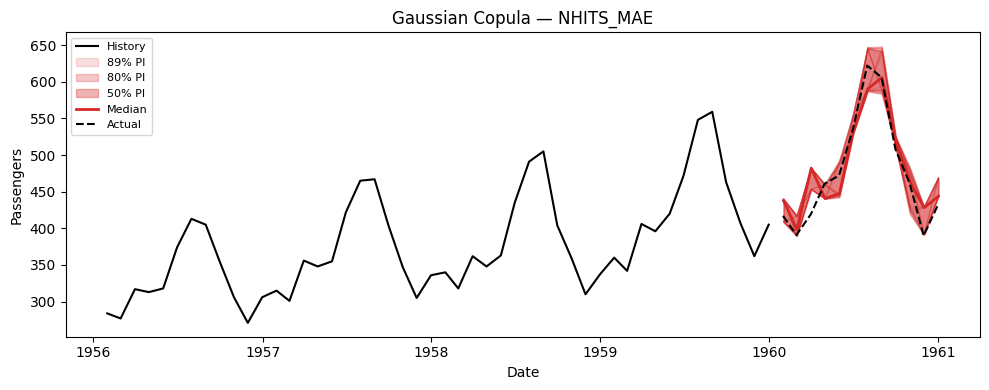

In [9]:
# Extract (n_paths, H) arrays for plotting
model_cols = [c for c in sim_df.columns if c not in ("unique_id", "ds", "sample_id")]

for model_col in model_cols:
    sims = extract_sims(sim_df, model_col)
    print(f"{model_col}: simulation paths shape = {sims.shape}")
    plot_simulations(Y_train_df, sims, model_col, "Gaussian Copula", color="tab:red")

## 6. Using Simulation Paths for Decision-Making

The key advantage of simulation paths over prediction intervals is answering **joint** probabilistic questions. Here are concrete examples.

### Example: Probability of exceeding a cumulative threshold

Suppose we have a capacity of 5,800 total passengers over the next 12 months. What is the probability of exceeding this capacity?

This question requires the **joint** distribution — it cannot be answered from marginal intervals.

P(total passengers > 5,800) = 35.4%
Expected total passengers = 5,783
5th percentile = 5,720
95th percentile = 5,851


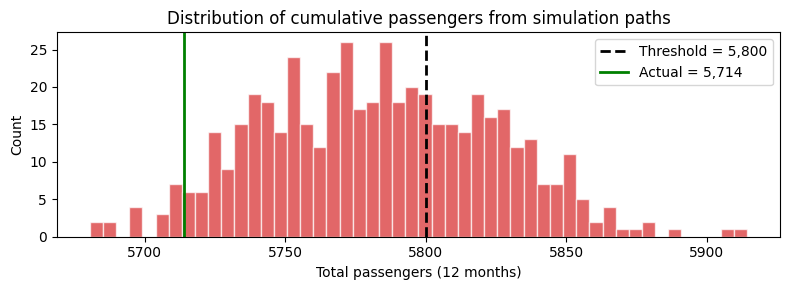

In [10]:
THRESHOLD = 5800

# Use NHITS_GMM simulations
sims_gmm = extract_sims(sim_df, "NHITS_GMM")
cumulative_passengers = sims_gmm.sum(axis=1)  # Sum across H=12 months per path
prob_exceed = (cumulative_passengers > THRESHOLD).mean()

print(f"P(total passengers > {THRESHOLD:,}) = {prob_exceed:.1%}")
print(f"Expected total passengers = {cumulative_passengers.mean():,.0f}")
print(f"5th percentile = {np.quantile(cumulative_passengers, 0.05):,.0f}")
print(f"95th percentile = {np.quantile(cumulative_passengers, 0.95):,.0f}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(cumulative_passengers, bins=50, color="tab:red", alpha=0.7, edgecolor="white")
ax.axvline(THRESHOLD, color="black", linestyle="--", linewidth=2, label=f"Threshold = {THRESHOLD:,}")
ax.axvline(Y_test_df["y"].sum(), color="green", linestyle="-", linewidth=2, label=f"Actual = {Y_test_df['y'].sum():,.0f}")
ax.set_xlabel("Total passengers (12 months)")
ax.set_ylabel("Count")
ax.set_title("Distribution of cumulative passengers from simulation paths")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Comparing Simulation Methods: Gaussian Copula vs. Schaake Shuffle

Both methods use the same marginal quantile forecasts but differ in how they introduce temporal correlation across horizon steps. Let's compare them on the **NHITS_Normal** model.

In [ ]:
# Generate paths with both methods
sim_copula = nf.simulate(n_paths=N_PATHS, seed=SEED, method="gaussian_copula")
sim_schaake = nf.simulate(n_paths=N_PATHS, seed=SEED, method="schaake_shuffle")

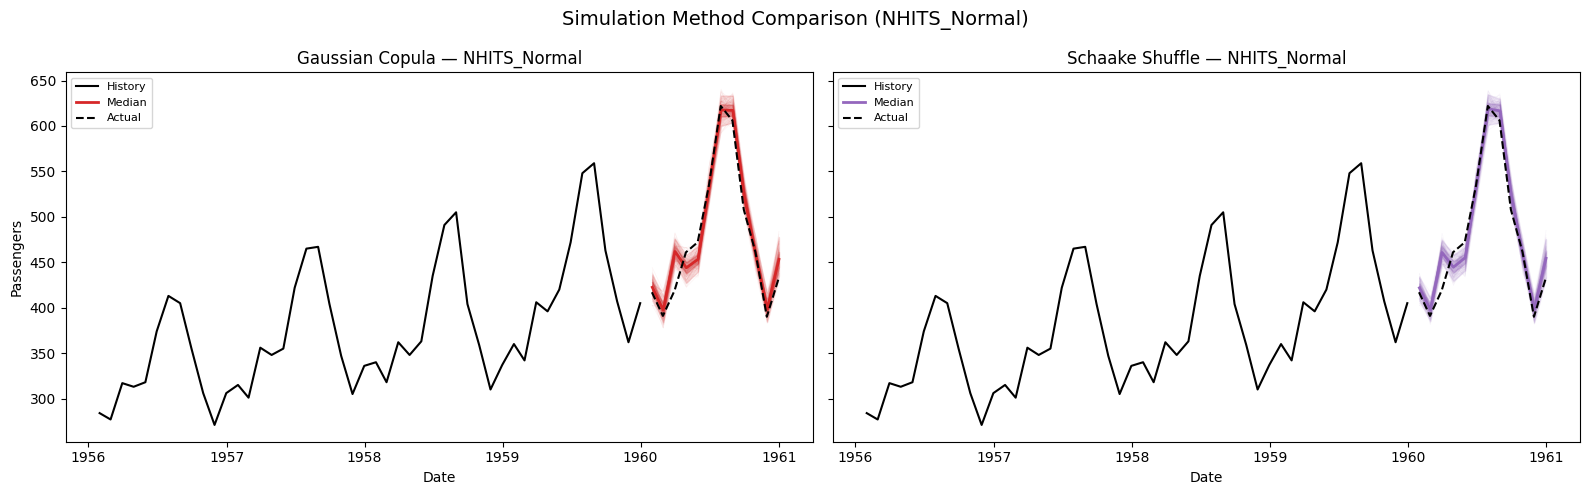

In [12]:

sims_copula = extract_sims(sim_copula, "NHITS_Normal")
sims_schaake = extract_sims(sim_schaake, "NHITS_Normal")

# Side-by-side path comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
hist = Y_train_df.sort_values("ds").tail(48)
last_date = hist["ds"].iloc[-1]
future_dates = pd.date_range(start=last_date, periods=H + 1, freq="MS")[1:]

for ax, sims, title, color in zip(
    axes,
    [sims_copula, sims_schaake],
    ["Gaussian Copula", "Schaake Shuffle"],
    ["tab:red", "tab:purple"],
):
    ax.plot(hist["ds"], hist["y"], color="black", linewidth=1.5, label="History")
    for i in range(min(100, sims.shape[0])):
        ax.plot(future_dates, sims[i], color=color, alpha=0.05, linewidth=0.5)
    for q_lo, q_hi, alpha in [(0.05, 0.95, 0.15), (0.25, 0.75, 0.30)]:
        lo = np.quantile(sims, q_lo, axis=0)
        hi = np.quantile(sims, q_hi, axis=0)
        ax.fill_between(future_dates, lo, hi, color=color, alpha=alpha)
    median = np.median(sims, axis=0)
    ax.plot(future_dates, median, color=color, linewidth=2, label="Median")
    ax.plot(Y_test_df["ds"], Y_test_df["y"], color="black", linestyle="--", label="Actual")
    ax.set_title(f"{title} — NHITS_Normal")
    ax.set_xlabel("Date")
    ax.legend(loc="upper left", fontsize=8)

axes[0].set_ylabel("Passengers")
plt.suptitle("Simulation Method Comparison (NHITS_Normal)", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Evaluating Marginal vs. Joint Distributions

We can evaluate both the **marginal** distribution (from `predict(quantiles=...)`) and the **joint** distribution (from `simulate()`) using the same metrics. For each model we compare:

- **Point metrics**: MAE, MSE on the median forecast.
- **Probabilistic metric**: scaled CRPS on the quantile forecasts — either from `predict` (marginal) or derived from simulation paths (joint).

If the simulation paths are well-calibrated, their empirical quantiles should score comparably to the model's native marginal quantiles.

In [ ]:
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, mse, scaled_crps

# ── Quantile grid for evaluation ──
eval_quantiles = np.round(np.arange(0.1, 1.0, 0.1), 2).tolist()  # [0.1, 0.2, ..., 0.9]

# We'll evaluate NHITS_Normal only for clarity
MODEL = "NHITS_Normal"

# ── 1. Marginal quantiles from predict() ──
marginal_df = nf.predict(quantiles=eval_quantiles)
# Add actuals — align by position (predict uses freq="MS" dates, test data has month-end dates)
marginal_df = marginal_df.sort_values(["unique_id", "ds"]).reset_index(drop=True)
marginal_df["y"] = Y_test_df.sort_values(["unique_id", "ds"])["y"].values

# ── 2. Joint quantiles derived from simulation paths (gaussian_copula) ──
sims_gc = extract_sims(sim_copula, MODEL)  # (n_paths, H)

joint_gc_df = marginal_df[["unique_id", "ds", "y"]].copy()
for q in eval_quantiles:
    joint_gc_df[f"{MODEL}_ql{q}"] = np.quantile(sims_gc, q, axis=0)
joint_gc_df[MODEL] = np.median(sims_gc, axis=0)

# ── 3. Joint quantiles derived from simulation paths (schaake_shuffle) ──
sims_ss = extract_sims(sim_schaake, MODEL)  # (n_paths, H)

joint_ss_df = marginal_df[["unique_id", "ds", "y"]].copy()
for q in eval_quantiles:
    joint_ss_df[f"{MODEL}_ql{q}"] = np.quantile(sims_ss, q, axis=0)
joint_ss_df[MODEL] = np.median(sims_ss, axis=0)

In [14]:
# ── Evaluate point metrics (via evaluate) ──
point_marginal = evaluate(marginal_df, metrics=[mae, mse], models=[MODEL], agg_fn="mean")
point_gc = evaluate(joint_gc_df, metrics=[mae, mse], models=[MODEL], agg_fn="mean")
point_ss = evaluate(joint_ss_df, metrics=[mae, mse], models=[MODEL], agg_fn="mean")

# ── Evaluate scaled CRPS (called directly — evaluate expects level-style columns) ──
quantile_cols = {MODEL: [f"{MODEL}_ql{q}" for q in eval_quantiles]}
quantiles_arr = np.array(eval_quantiles)

crps_marginal = scaled_crps(marginal_df, models=quantile_cols, quantiles=quantiles_arr)
crps_gc = scaled_crps(joint_gc_df, models=quantile_cols, quantiles=quantiles_arr)
crps_ss = scaled_crps(joint_ss_df, models=quantile_cols, quantiles=quantiles_arr)

# ── Combine results ──
results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "Scaled CRPS"],
    "Marginal (predict)": [
        point_marginal[MODEL].values[0],
        point_marginal[MODEL].values[1],
        crps_marginal[MODEL].mean(),
    ],
    "Joint — Gaussian Copula": [
        point_gc[MODEL].values[0],
        point_gc[MODEL].values[1],
        crps_gc[MODEL].mean(),
    ],
    "Joint — Schaake Shuffle": [
        point_ss[MODEL].values[0],
        point_ss[MODEL].values[1],
        crps_ss[MODEL].mean(),
    ],
}).set_index("Metric")

print(f"Model: {MODEL}")
results

Model: NHITS_Normal


,Marginal (predict),Joint — Gaussian Copula,Joint — Schaake Shuffle
Metric,,,
MAE,12.669571,12.942172,12.516764
MSE,276.954919,288.357154,275.652889
Scaled CRPS,0.021440,0.022133,0.021545


**Interpreting the results:**

- **MAE / MSE** (point metrics): Both simulation methods use the median of the sample paths as their point forecast. Since the marginal quantiles and simulation-derived quantiles share the same underlying model, the median forecasts are similar but not identical — simulation introduces sampling variability.
- **Scaled CRPS** (probabilistic metric): Measures the quality of the full quantile distribution. The marginal quantiles come directly from the model's predictive distribution, while the simulation-derived quantiles are empirical (computed from `n_paths` samples). With enough paths, the simulation CRPS should converge to the marginal CRPS.

## 9. Summary

| Question | Use |
|----------|-----|
| "What range is step $h$ likely in?" | `predict(level=...)` — prediction intervals |
| "What are realistic joint future trajectories?" | `simulate(n_paths=...)` — sample paths |
| "What is P(total > threshold)?" | `simulate()` then sum paths |
| "What is P(3 consecutive spikes)?" | `simulate()` then check path patterns |
| "What is the CVaR of my portfolio?" | `simulate()` then compute tail statistics |

### Simulation Methods

| Method | Use when... |
|--------|-------------|
| `gaussian_copula` (default) | You want smooth, parametric temporal correlation (AR(1) structure). Fast and robust. |
| `schaake_shuffle` | You want nonparametric dependence from historical data. Captures asymmetric / non-Gaussian correlation patterns. |

### Compatible Losses

| Loss type | How quantiles are obtained |
|-----------|---------------------------|
| `DistributionLoss`, `GMM`, `PMM`, `NBMM` | Arbitrary quantiles from parametric distribution |
| `MQLoss` / `HuberMQLoss` | Uses the model's trained quantile grid |
| `IQLoss` / `HuberIQLoss` | Multiple forward passes, one per quantile |
| Point losses (`MAE`, `MSE`, etc.) | Conformal Prediction intervals (requires `prediction_intervals` during `fit()`) |

### References
- Baron, E. et al. (2025). [Efficiently generating correlated sample paths from multi-step time series foundation models](https://arxiv.org/abs/2510.02224). NeurIPS 2025 Workshop.
- Clark, M. et al. (2004). The Schaake shuffle: A method for reconstructing space-time variability. *Journal of Hydrometeorology*, 5(1).